In [2]:
import pandas as pd

df = pd.read_csv('q2_customers.csv')
df.head()

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,30,43075,9,2080,45,6
1,19,14496,11,454,8,3
2,43,57632,6,2144,16,4
3,30,15629,10,801,0,2
4,19,14901,16,396,17,1


In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

Feature scaling is important for K-Means because it is a distance-based algorithm.
If features are on different scales (e.g., income vs visits), larger values dominate the clustering.
StandardScaler ensures all features contribute equally.

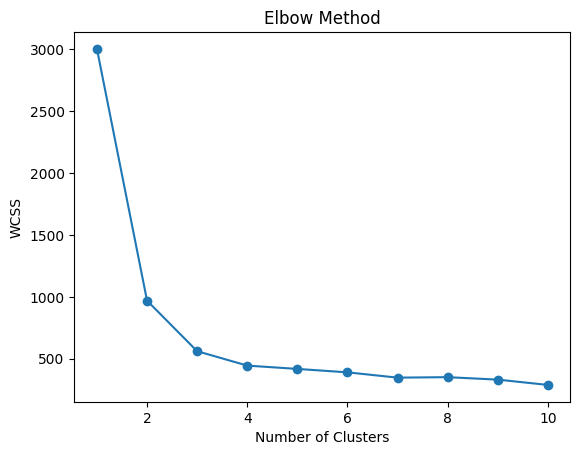

In [4]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

The optimal number of clusters is chosen at the elbow point where the WCSS starts to decrease slowly.
This indicates that adding more clusters does not significantly improve the model.

In [5]:
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(scaled_data)

In [6]:
centroids = pd.DataFrame(
    scaler.inverse_transform(kmeans.cluster_centers_),
    columns=df.columns[:-1]
)

centroids

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
0,24.676471,14847.370588,14.341176,558.970588,9.076471,2.111765
1,56.769697,89413.333333,2.527273,5530.545455,105.357576,7.515152
2,40.387879,43340.733333,8.193939,2021.684848,35.187879,4.424242


Cluster 0: High spenders with low visit frequency.
Cluster 1: Frequent visitors with low basket size.
Cluster 2: Moderate customers with balanced behavior.

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])

In [8]:
print(pca.explained_variance_ratio_)

[0.83560354 0.05568764]


In [9]:
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[:-1],
    index=['PC1', 'PC2']
)

loadings

,age,annual_spend,visits_per_month,basket_size,days_since_last_visit,num_categories_purchased
PC1,0.411569,0.42154,-0.410399,0.412012,0.378582,0.414017
PC2,-0.259432,-0.03327,0.208318,-0.195402,0.911194,-0.140479


PC1 captures overall spending behavior (annual spend, basket size).
PC2 captures customer activity (visits per month, recency).


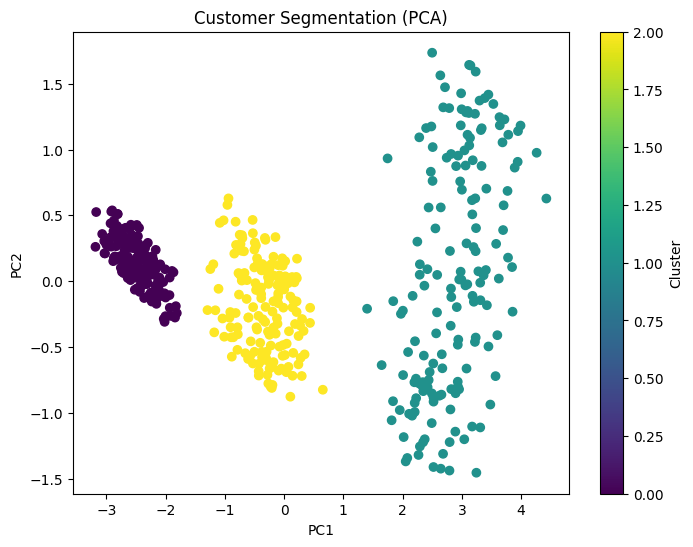

In [10]:
plt.figure(figsize=(8,6))
plt.scatter(pca_df['PC1'], pca_df['PC2'], c=df['cluster'])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Customer Segmentation (PCA)')
plt.colorbar(label='Cluster')
plt.show()

K-Means clustering successfully segmented customers into distinct groups, helping businesses target different customer types effectively.